# Actividad 1 - Regresión Lineal (Boston Housing)

## Introducción

El dataset Boston Housing contiene información sobre viviendas en Boston, incluyendo características como cantidad de habitaciones, nivel de criminalidad, impuestos, entre otros.

El objetivo es analizar la relación entre estas variables y el precio de las viviendas (medv), que representa el valor medio de las casas.

En esta actividad se utiliza regresión lineal para predecir el precio de la vivienda a partir de la cantidad de habitaciones (rm).

In [1]:
# Importamos librerías
import pandas as pd

# Cargamos el dataset
df = pd.read_csv("BostonHousing.csv")

# Mostramos las primeras filas
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [2]:
# Información general del dataset
df.info()

# Estadísticas básicas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [3]:
# Verificamos valores faltantes
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [4]:
# Verificamos valores faltantes
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

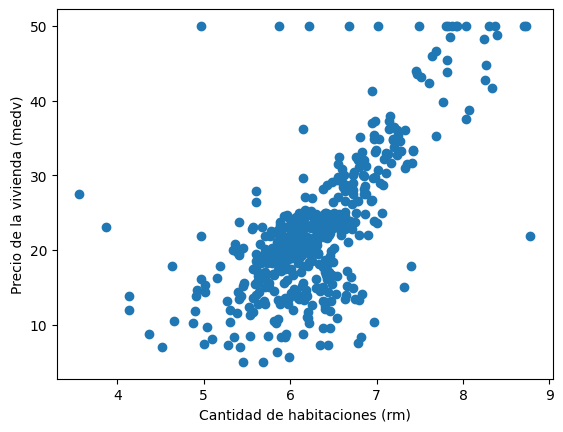

In [5]:
# Importamos matplotlib
import matplotlib.pyplot as plt

# Gráfico de dispersión (rm vs medv)
plt.scatter(df["rm"], df["medv"])
plt.xlabel("Cantidad de habitaciones (rm)")
plt.ylabel("Precio de la vivienda (medv)")
plt.show()

In [6]:
# Importamos modelo
from sklearn.linear_model import LinearRegression

# Definimos variables (simple)
X = df[["rm"]]
y = df["medv"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Creamos modelo
modelo = LinearRegression()

# Entrenamos
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Predicción
y_pred = modelo.predict(X_test)

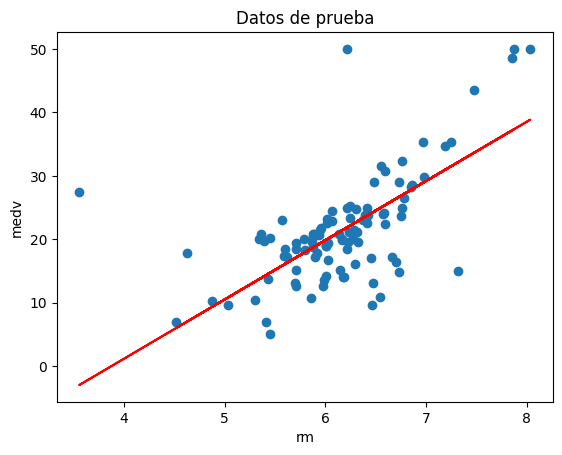

In [8]:
import matplotlib.pyplot as plt

# Datos de prueba reales
plt.scatter(X_test, y_test)

# Predicción del modelo
plt.plot(X_test, y_pred, color="red")

plt.xlabel("rm")
plt.ylabel("medv")
plt.title("Datos de prueba")
plt.show()

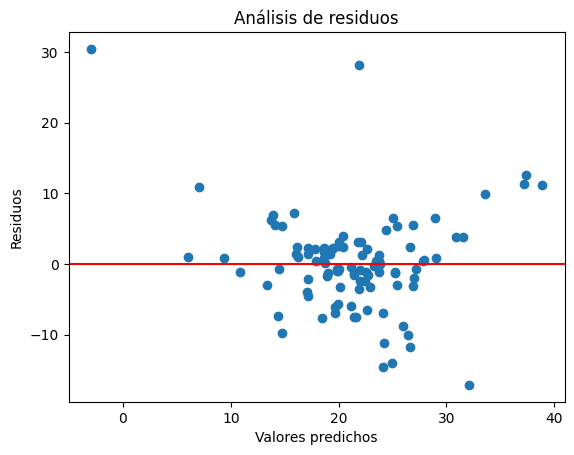

In [9]:
# Calculamos residuos
residuos = y_test - y_pred

# Graficamos residuos
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuos)
plt.axhline(y=0, color="red")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Análisis de residuos")
plt.show()

## Análisis de métricas y residuos

Se calcularon métricas para evaluar el desempeño del modelo de regresión lineal.

El MAE indica el error promedio absoluto entre los valores reales y predichos.  
El MSE mide el error cuadrático promedio.  
El R2 indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

También se realizó un análisis de residuos para observar la diferencia entre los valores reales y los valores predichos.

## Conclusión

Se aplicó regresión lineal utilizando la variable "rm" para predecir "medv".

Se observa una relación positiva: a mayor cantidad de habitaciones, mayor precio de la vivienda.

El modelo presenta un ajuste aceptable, con un valor de R² que indica que una parte importante de la variabilidad del precio es explicada por el modelo.

A partir de las métricas (MAE y MSE) se observa que existen errores de predicción, lo cual es esperable al trabajar con datos reales.

El análisis de residuos muestra una dispersión alrededor de cero, sin patrones claros, lo que indica que el modelo no presenta errores sistemáticos importantes.